# **AI Based Speaker Classification**

## **Set-Up**

In [241]:
# Base Python libraries
import pandas as pd
import numpy as np
import re
import os
from tqdm import tqdm
import json

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# llm libraries
import ollama
from ollama import Client
import mistralai

### **Load Data**

In [242]:
raw_data = pd.read_csv("data/UWSM_Community_Input_Transcripts_Split.csv")

print("--"*50)
print("Raw Data Shape:")
print(raw_data.shape)
print("--"*50)

----------------------------------------------------------------------------------------------------
Raw Data Shape:
(1769, 11)
----------------------------------------------------------------------------------------------------


In [243]:
# view first few rows
print("--"*50)
print("Raw Data Sample")
print("--"*50)
raw_data

----------------------------------------------------------------------------------------------------
Raw Data Sample
----------------------------------------------------------------------------------------------------


,Source File,Name of Facilitator(s),Date of Conversation,Name of Organization/Group,Meeting Location,Length of Time,Number of Attendees,Population,Summary Keywords,Speaker,Text
0,"EFO_AvestaOOB_York County, Older Adults, Rente...",Pamela Bennett,3/17/26,AVESTA residents,OOB,NaN,8,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Affordable housing, food insecurity, community...",Speaker 1,"This is Pamela, and it's March 17, and I am at..."
1,"EFO_AvestaOOB_York County, Older Adults, Rente...",Pamela Bennett,3/17/26,AVESTA residents,OOB,NaN,8,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Affordable housing, food insecurity, community...",Speaker 2,School System. The school system is specific t...
2,"EFO_AvestaOOB_York County, Older Adults, Rente...",Pamela Bennett,3/17/26,AVESTA residents,OOB,NaN,8,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Affordable housing, food insecurity, community...",Speaker 3,I think the police department and fire departm...
3,"EFO_AvestaOOB_York County, Older Adults, Rente...",Pamela Bennett,3/17/26,AVESTA residents,OOB,NaN,8,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Affordable housing, food insecurity, community...",Speaker 1,Any other strengths have to be specific to Old...
4,"EFO_AvestaOOB_York County, Older Adults, Rente...",Pamela Bennett,3/17/26,AVESTA residents,OOB,NaN,8,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Affordable housing, food insecurity, community...",Speaker 1,friendship that we all have. We care for each ...
...,...,...,...,...,...,...,...,...,...,...,...
1764,EFO_YLAT_3-11-26_Nina_Draft.txt,Lee Klarman,"Thu, Mar 12, 2026 12:09PM",YLAT,NaN,51:45,Population - identify one or more of the follo...,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Community values, foster care system, mutual a...",Speaker 6,like friendship reasons. Can be a friendship r...
1765,EFO_YLAT_3-11-26_Nina_Draft.txt,Lee Klarman,"Thu, Mar 12, 2026 12:09PM",YLAT,NaN,51:45,Population - identify one or more of the follo...,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Community values, foster care system, mutual a...",Speaker 1,So I'm just gonna read some of the ones we hav...
1766,EFO_YLAT_3-11-26_Nina_Draft.txt,Lee Klarman,"Thu, Mar 12, 2026 12:09PM",YLAT,NaN,51:45,Population - identify one or more of the follo...,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Community values, foster care system, mutual a...",Speaker 1,"by fast, I know well. Thank you all so so much..."
1767,EFO_YLAT_3-11-26_Nina_Draft.txt,Lee Klarman,"Thu, Mar 12, 2026 12:09PM",YLAT,NaN,51:45,Population - identify one or more of the follo...,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Community values, foster care system, mutual a...",Speaker 4,learn more about your organizations? Do you ha...


In [290]:
print(raw_data.columns)

Index(['Source File', 'Name of Facilitator(s)', 'Date of Conversation',
       'Name of Organization/Group', 'Meeting Location', 'Length of Time',
       'Number of Attendees', 'Population', 'Summary Keywords', 'Speaker',
       'Text'],
      dtype='str')


In [244]:
combined = (
    raw_data.groupby(['Source File', 'Speaker'], sort=False, as_index=False)['Text']
      .agg(' '.join)
)
print("--"*50)
print("Combined Data Sample")
print("--"*50)
combined

----------------------------------------------------------------------------------------------------
Combined Data Sample
----------------------------------------------------------------------------------------------------


,Source File,Speaker,Text
0,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 1,"This is Pamela, and it's March 17, and I am at..."
1,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 2,School System. The school system is specific t...
2,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 3,I think the police department and fire departm...
3,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 4,"No Everybody minds their own business, but the..."
4,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 6,"There's a lot of places to go walking, if you ..."
...,...,...,...
185,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 5,"I think, when I think about the lilac communit..."
186,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 6,a real it's a real challenge. Do you like abou...
187,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 7,"meaning, I would say that's about a person, bu..."
188,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 8,similar to what I was going what I was going t...


In [245]:
combined[combined["Source File"] == "EFO_YLAT_3-11-26_Nina_Draft.txt"]

,Source File,Speaker,Text
181,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 1,"Okay, so this is why lat on March 11, absolute..."
182,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 2,"So the first question that we have for you, it..."
183,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 3,"Just to clarify, are you saying everyone, indi..."
184,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 4,"She wants to just speak out loud, yeah, go for..."
185,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 5,"I think, when I think about the lilac communit..."
186,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 6,a real it's a real challenge. Do you like abou...
187,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 7,"meaning, I would say that's about a person, bu..."
188,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 8,similar to what I was going what I was going t...
189,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 9,"I wonder, like, just generally, if we brought ..."


## **Ollama - qwen2.5:14b**

In [246]:
# ---------- Config ----------
MODEL = "qwen2.5:14b"
VALID_LABELS = {"Facilitator", "ALICE", "Above ALICE"}
NON_FACILITATOR_LABELS = {"ALICE", "Above ALICE"}

client = Client(host="http://localhost:11434")

# ---------- Prompt ----------
SYSTEM_PROMPT = """You classify transcript segments into ONE label:

Labels:
1. Facilitator
2. ALICE
3. Above ALICE

Definitions:

Facilitator:
- Asks questions, guides discussion, transitions topics
- Neutral tone, no personal opinions or experiences
- Manages participation or summarizes others
- Does not share personal financial details or struggles

ALICE:
- ALICE stands for Asset Limited, Income Constrained, Employed. This group includes individuals and families who earn above the federal poverty level but struggle to afford basic necessities.
- Describes personal financial struggle or instability
- Mentions bills, rent, food, healthcare, tradeoffs
- Expresses stress, survival, or lack of access to resources

Above ALICE:
- Engages with community issues from a position of stability 
- Concerned, but not personally at risk
- Financially stable or secure
- Talks about savings, investments, homeownership, planning
- May discuss issues abstractly or show concern for others, not self

Decision Rules:
- Pick ONE label only
- If both facilitator + participant appear → choose dominant speaker
- Facilitator cues: asking questions "?", guiding discussion, summarizing others
- If unclear between ALICE vs Above ALICE:
  - Personal struggle → ALICE
  - Stable perspective → Above ALICE

Confidence Scale (1-5):

5 - DEFINITIVE
  - 3+ direct quotes unambiguously support the label
  - Zero competing signals from other labels
  - Tone, language, and context all align consistently

4 - PROBABLE
  - 2+ signals clearly support the label
  - At most 1 weak competing signal present
  - Overall context supports the assigned label

3 - MODERATE
  - 1-2 signals support the label
  - At least 1 competing signal from another label exists
  - Context partially supports but is not conclusive

2 - UNCERTAIN
  - Only 1 weak signal supports the label
  - Multiple competing signals from other labels
  - Assignment is the closest match, not a clear fit

1 - INDETERMINATE → FLAG FOR MANUAL REVIEW
  - No direct signals found
  - Competing signals are equal across labels
  - Do not trust this classification

Output format (STRICT):
{"label": "<Facilitator|ALICE|Above ALICE>", "confidence": <1-5>, "confidence_label": "<Definitive|Probable|Moderate|Uncertain|Indeterminate>"}
"""

NON_FACILITATOR_PROMPT = """Classify the transcript segment into ONE label:

Labels:
- ALICE
- Above ALICE

Definitions:

ALICE:
- ALICE stands for Asset Limited, Income Constrained, Employed. This group includes individuals and families who earn above the federal poverty level but struggle to afford basic necessities.
- Describes personal financial struggle or instability
- Mentions bills, rent, food, healthcare, tradeoffs
- Expresses stress, survival, or lack of access to resources

Above ALICE:
- Engages with community issues from a position of stability 
- Concerned, but not personally at risk
- Financially stable or secure
- Talks about savings, investments, homeownership, planning
- May discuss issues abstractly or show concern for others, not self

Decision Rules:
- Pick ONE label only
- If both facilitator + participant appear → choose dominant speaker
- Facilitator cues: asking questions "?", guiding discussion, summarizing others
- If unclear between ALICE vs Above ALICE:
  - Personal struggle → ALICE
  - Stable perspective → Above ALICE

Confidence Scale (1-5):

5 - DEFINITIVE
  - 3+ direct quotes unambiguously support the label
  - Zero competing signals from other labels
  - Tone, language, and context all align consistently

4 - PROBABLE
  - 2+ signals clearly support the label
  - At most 1 weak competing signal present
  - Overall context supports the assigned label

3 - MODERATE
  - 1-2 signals support the label
  - At least 1 competing signal from another label exists
  - Context partially supports but is not conclusive

2 - UNCERTAIN
  - Only 1 weak signal supports the label
  - Multiple competing signals from other labels
  - Assignment is the closest match, not a clear fit

1 - INDETERMINATE → FLAG FOR MANUAL REVIEW
  - No direct signals found
  - Competing signals are equal across labels
  - Do not trust this classification

Output format (STRICT):
{"label": "<Facilitator|ALICE|Above ALICE>", "confidence": <1-5>, "confidence_label": "<Definitive|Probable|Moderate|Uncertain|Indeterminate>"}

"""

In [247]:
def classify_text(text: str, retries: int = 2) -> dict:
    """Classify a single text segment. Returns {'label': str, 'confidence': float}."""
    for attempt in range(retries + 1):
        try:
            response = client.chat(
                model=MODEL,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": f"Classify this text:\n\n{text}"},
                ],
                format="json",            # forces valid JSON output
                options={
                    "temperature": 0,     # deterministic for classification
                    "num_ctx": 4096,      # adjust if your segments are long
                },
            )
            raw = response["message"]["content"]
            parsed = json.loads(raw)
            
            label = parsed.get("label", "").strip()
            confidence = float(parsed.get("confidence", 0.0))
            
            if label not in VALID_LABELS:
                raise ValueError(f"Invalid label returned: {label}")
            
            return {"label": label, "confidence": confidence}
        
        except (json.JSONDecodeError, ValueError, KeyError) as e:
            if attempt == retries:
                return {"label": "ERROR", "confidence": 0.0, "error": str(e)}
            continue

In [248]:
# label and confidence
labels = []
confidences = []

for _, row in tqdm(combined.iterrows(), total=combined.shape[0]):
    text = row["Text"]
    result = classify_text(text)
    labels.append(result["label"])
    confidences.append(result["confidence"])

# Add results to combined DataFrame
combined["Predicted Label"] = labels
combined["Confidence"] = confidences


100%|██████████| 190/190 [32:09<00:00, 10.15s/it] 


In [249]:
combined

,Source File,Speaker,Text,Predicted Label,Confidence
0,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 1,"This is Pamela, and it's March 17, and I am at...",Facilitator,5.0
1,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 2,School System. The school system is specific t...,Above ALICE,3.0
2,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 3,I think the police department and fire departm...,Facilitator,4.0
3,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 4,"No Everybody minds their own business, but the...",ALICE,4.0
4,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 6,"There's a lot of places to go walking, if you ...",Above ALICE,3.0
...,...,...,...,...,...
185,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 5,"I think, when I think about the lilac communit...",ALICE,4.0
186,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 6,a real it's a real challenge. Do you like abou...,Facilitator,4.0
187,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 7,"meaning, I would say that's about a person, bu...",Above ALICE,4.0
188,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 8,similar to what I was going what I was going t...,ALICE,4.0


**Resolving Duel Facilitator Ambiguity**

In [250]:
def alice_non_alice(text: str, retries: int = 2) -> dict:
    """Classify a single text segment. Returns {'label': str, 'confidence': float}."""
    for attempt in range(retries + 1):
        try:
            response = client.chat(
                model=MODEL,
                messages=[
                    {"role": "system", "content": NON_FACILITATOR_PROMPT},
                    {"role": "user", "content": f"Classify this text:\n\n{text}"},
                ],
                format="json",            # forces valid JSON output
                options={
                    "temperature": 0,     # deterministic for classification
                    "num_ctx": 4096,      # adjust if your segments are long
                },
            )
            raw = response["message"]["content"]
            parsed = json.loads(raw)
            
            label = parsed.get("label", "").strip()
            confidence = float(parsed.get("confidence", 0.0))
            
            if label not in VALID_LABELS:
                raise ValueError(f"Invalid label returned: {label}")
            
            return {"label": label, "confidence": confidence}
        
        except (json.JSONDecodeError, ValueError, KeyError) as e:
            if attempt == retries:
                return {"label": "ERROR", "confidence": 0.0, "error": str(e)}
            continue

**Solving Multiple Facilitator Issue**

In [251]:
for source in combined["Source File"].unique():

    mask = (
        (combined["Source File"] == source) &
        (combined["Predicted Label"] == "Facilitator")
    )

    subset = combined.loc[mask]

    if len(subset) <= 1:
        continue  # Already fine, skip

    # Find the single best Facilitator
    best_idx = subset["Confidence"].idxmax()

    # Every other Facilitator in this file gets re-evaluated
    other_indices = [idx for idx in subset.index if idx != best_idx]

    for idx in other_indices:
        text = combined.loc[idx, "Text"]
        result = alice_non_alice(text)

        combined.loc[idx, "Predicted Label"] = result["label"]
        combined.loc[idx, "Confidence"] = result["confidence"]

**Solving ALICE vs Above-ALICE Ambiguity**

In [252]:
mask = (
    (combined["Predicted Label"] == "Above ALICE") &
    (combined["Confidence"] < 0.5)
)

indices = combined.index[mask]

for idx in indices:
    text = combined.loc[idx, "Text"]
    result = alice_non_alice(text)

    combined.loc[idx, "Predicted Label"] = result["label"]
    combined.loc[idx, "Confidence"] = result["confidence"]

In [253]:
combined.to_csv("data/UWSM_Combined_Labeled.csv", index=False)

In [254]:
combined

,Source File,Speaker,Text,Predicted Label,Confidence
0,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 1,"This is Pamela, and it's March 17, and I am at...",Facilitator,5.0
1,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 2,School System. The school system is specific t...,Above ALICE,3.0
2,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 3,I think the police department and fire departm...,Above ALICE,3.0
3,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 4,"No Everybody minds their own business, but the...",ALICE,4.0
4,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 6,"There's a lot of places to go walking, if you ...",Above ALICE,3.0
...,...,...,...,...,...
185,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 5,"I think, when I think about the lilac communit...",ALICE,4.0
186,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 6,a real it's a real challenge. Do you like abou...,ERROR,0.0
187,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 7,"meaning, I would say that's about a person, bu...",Above ALICE,4.0
188,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 8,similar to what I was going what I was going t...,ALICE,4.0


**Santity Check**

In [255]:
len(combined[combined["Predicted Label"] == "Facilitator"])

24

In [256]:
for count, source in enumerate(combined["Source File"].unique()):
    print(f"{count}: Source File: {source}")
    subset = combined[(combined["Source File"] == source) & (combined["Predicted Label"] == "Facilitator")]
    print(subset[["Speaker", "Confidence"]])
    print("--"*50)


0: Source File: EFO_AvestaOOB_York County, Older Adults, Renters.txt
     Speaker  Confidence
0  Speaker 1         5.0
----------------------------------------------------------------------------------------------------
1: Source File: EFO_Bartlett Woods_York County, Older Adults, Urban, ALICE.txt
     Speaker  Confidence
9  Speaker 1         5.0
----------------------------------------------------------------------------------------------------
2: Source File: EFO_Biddeford Resiliency_York County, Under 25, Rural, Serves ALICE.txt
      Speaker  Confidence
18  Speaker 1         5.0
----------------------------------------------------------------------------------------------------
3: Source File: EFO_BridgtonLibrary_Cumberland County, Rural, Some ALICE.txt
      Speaker  Confidence
26  Speaker 1         5.0
----------------------------------------------------------------------------------------------------
4: Source File: EFO_ELU 2-18-2026 Val - Cumberland County, Urban, Above ALICE, 

### **Prediction Distribution**

In [257]:
summary = (
    combined
    .groupby("Predicted Label")
    .agg(
        mean_confidence=("Confidence", "mean"),
        frequency=("Predicted Label", "count")
    )
    .reset_index()
)

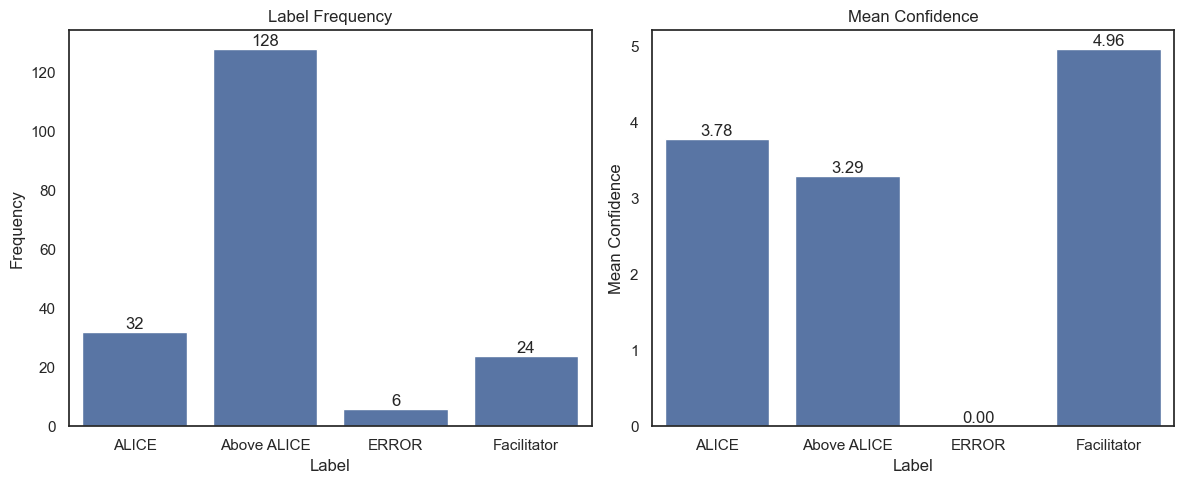

In [258]:
sns.set_style("white")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Frequency Plot ---
sns.barplot(
    data=summary,
    x="Predicted Label",
    y="frequency",
    ax=axes[0]
)

axes[0].set_title("Label Frequency")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Frequency")

# Add value labels
for i, v in enumerate(summary["frequency"]):
    axes[0].text(i, v, str(v), ha='center', va='bottom')

# --- Mean Confidence Plot ---
sns.barplot(
    data=summary,
    x="Predicted Label",
    y="mean_confidence",
    ax=axes[1]
)

axes[1].set_title("Mean Confidence")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Mean Confidence")

# Add value labels
for i, v in enumerate(summary["mean_confidence"]):
    axes[1].text(i, v, f"{v:.2f}", ha='center', va='bottom')

# Remove gridlines explicitly (extra safety)
for ax in axes:
    ax.grid(False)

plt.tight_layout()
plt.show()

In [259]:
alice_subset = combined[combined["Predicted Label"] == "ALICE"]
above_alice_subset = combined[combined["Predicted Label"] == "Above ALICE"]

In [260]:
print("--"*50)
print("ALICE Subset Shape:")
print(alice_subset.shape)
print("--"*50)
alice_subset.head(10)

----------------------------------------------------------------------------------------------------
ALICE Subset Shape:
(32, 5)
----------------------------------------------------------------------------------------------------


,Source File,Speaker,Text,Predicted Label,Confidence
3,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 4,"No Everybody minds their own business, but the...",ALICE,4.0
6,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 5,"gas in your car, or electricity bill. You've g...",ALICE,3.0
14,"EFO_Bartlett Woods_York County, Older Adults, ...",Speaker 6,Avesta never took charge. That's true. We just...,ALICE,3.0
16,"EFO_Bartlett Woods_York County, Older Adults, ...",Speaker 9,"You get a hold of Jean, okay? What she does is...",ALICE,3.0
24,"EFO_Biddeford Resiliency_York County, Under 25...",Speaker 7,"Uh, another thing I think that help that we do...",ALICE,4.0
29,"EFO_BridgtonLibrary_Cumberland County, Rural, ...",Speaker 4,I always really appreciate that people are wil...,ALICE,4.0
33,"EFO_BridgtonLibrary_Cumberland County, Rural, ...",Speaker 8,"Yeah, the sense of community is very clear. Th...",ALICE,4.0
36,"EFO_ELU 2-18-2026 Val - Cumberland County, Urb...",Speaker 3,"I can start, I would say in terms of thinking ...",ALICE,4.0
46,"EFO_GreatBay_3-3_York County, Rural, Some ALIC...",Speaker 6,"Well, just to go back on the mode of care issu...",ALICE,4.0
56,"EFO_MAIN_Cumberland, Urban, Immigrants, ALICE.txt",Speaker 2,Do you have something like that on your websit...,ALICE,4.0


----------------------------------------------------------------------------------------------------
Confidence Distribution for ALICE:
----------------------------------------------------------------------------------------------------


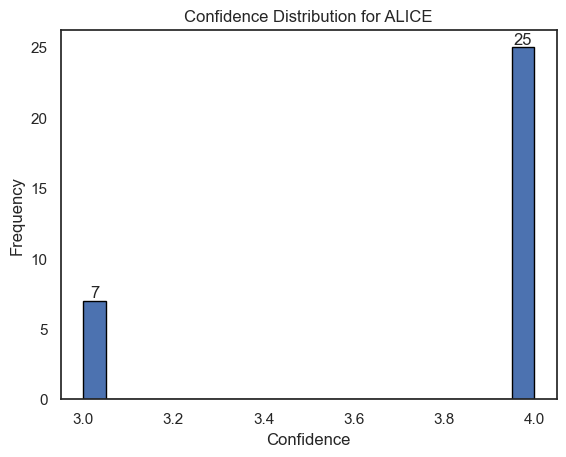

In [261]:
# Alice Category Distribution
print("--"*50)
print("Confidence Distribution for ALICE:")
print("--"*50)

sns.set_style("white")  # remove grid

fig, ax = plt.subplots()

# Plot histogram
counts, bins, patches = ax.hist(alice_subset["Confidence"], bins=20, edgecolor='black')

# Add frequency labels on top of bars
for count, patch in zip(counts, patches):
    if count > 0:  # avoid cluttering zeros
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            int(count),
            ha='center',
            va='bottom'
        )

ax.set_title("Confidence Distribution for ALICE")
ax.set_xlabel("Confidence")
ax.set_ylabel("Frequency")

ax.grid(False)  # ensure no grid

plt.show()

In [262]:
print("--"*50)
print("Above ALICE Subset Shape:")
print(above_alice_subset.shape)
print("--"*50)
above_alice_subset.head(10)

----------------------------------------------------------------------------------------------------
Above ALICE Subset Shape:
(128, 5)
----------------------------------------------------------------------------------------------------


,Source File,Speaker,Text,Predicted Label,Confidence
1,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 2,School System. The school system is specific t...,Above ALICE,3.0
2,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 3,I think the police department and fire departm...,Above ALICE,3.0
4,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 6,"There's a lot of places to go walking, if you ...",Above ALICE,3.0
5,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 8,We never go to the movie or anything. People a...,Above ALICE,3.0
7,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 7,"Did you smell it the other day, that warm day ...",Above ALICE,3.0
8,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 10,"I was saying, When are my kids are young, but ...",Above ALICE,3.0
10,"EFO_Bartlett Woods_York County, Older Adults, ...",Speaker 2,I lived in Yarmouth most of my life. I owned h...,Above ALICE,4.0
11,"EFO_Bartlett Woods_York County, Older Adults, ...",Speaker 3,I find it an extraordinarily friendly communit...,Above ALICE,4.0
12,"EFO_Bartlett Woods_York County, Older Adults, ...",Speaker 4,"I think that's true, that there are a lot more...",Above ALICE,4.0
13,"EFO_Bartlett Woods_York County, Older Adults, ...",Speaker 5,"Now, the thing that I really like about the co...",Above ALICE,4.0


----------------------------------------------------------------------------------------------------
Confidence Distribution for ABOVE ALICE:
----------------------------------------------------------------------------------------------------


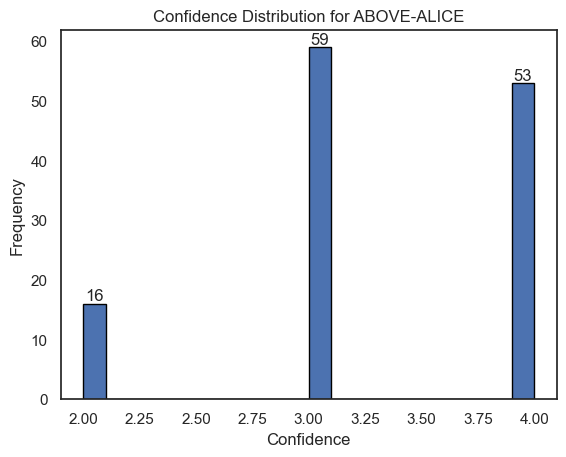

In [263]:
print("--"*50)
print("Confidence Distribution for ABOVE ALICE:")
print("--"*50)
sns.set_style("white")  # remove grid

fig, ax = plt.subplots()

# Plot histogram
counts, bins, patches = ax.hist(above_alice_subset["Confidence"], bins=20, edgecolor='black')

# Add frequency labels on top of bars
for count, patch in zip(counts, patches):
    if count > 0:  # avoid cluttering zeros
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            int(count),
            ha='center',
            va='bottom'
        )

ax.set_title("Confidence Distribution for ABOVE-ALICE")
ax.set_xlabel("Confidence")
ax.set_ylabel("Frequency")

ax.grid(False)  # ensure no grid

plt.show()

## **BERTopic Pipeline**

**Loading Important Libraires**

In [322]:
# Stopwords for text preprocessing
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.corpus import stopwords

# NLP and topic modeling libraries
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

# Supporting libraries
import torch
import gc
import time

**BGE-Large Embedding Generation**

In [323]:
# BGE M3 Implementation Code
bge_large = SentenceTransformer('BAAI/bge-large-en-v1.5')

print("--"*50)
print("BGE Large Model Loaded Successfully !!")
print("--"*50)
print("Model Details:")
print(f"Model loaded: BAAI/bge-large-en-v1.5")
print(f"Max sequence length: {bge_large.max_seq_length}")
print(f"Embedding dimension: {bge_large.get_sentence_embedding_dimension()}")
print(f"Number of layers: {len(bge_large[0].auto_model.encoder.layer)}")
print(f"Vocabulary size: {bge_large[0].auto_model.config.vocab_size}")
print("--"*50)

----------------------------------------------------------------------------------------------------
BGE Large Model Loaded Successfully !!
----------------------------------------------------------------------------------------------------
Model Details:
Model loaded: BAAI/bge-large-en-v1.5
Max sequence length: 512
Embedding dimension: 1024
Number of layers: 24
Vocabulary size: 30522
----------------------------------------------------------------------------------------------------


**Defining UMAP**

In [324]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42,
)


**Defining HDBSCAN**

In [325]:
hdbscan_model = HDBSCAN(
    min_samples=3,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
)

**WordCloud**

In [326]:
def wordcloud_for_topic(topic_model, topic_id):
    words = dict(topic_model.get_topic(topic_id))  # {word: c-tf-idf score}
    if not words:
        return None
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap='viridis',
    ).generate_from_frequencies(words)
    return wc

### **Defining and Cleaning text corpus**

In [327]:
# Cleanup to cleaning the conversations: removing extra spaces, newlines, and tabs
def clean_text(text):

    # Remove special characters and numbers, keep only letters and spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'[\n\r\t]+', ' ', text)

    # Convert to lowercase
    text = text.lower()
    return text

In [328]:
# Apllying clean text function
combined["clean_text"] = combined["Text"].apply(clean_text)

print("--"*50)
print("Cleaned Text Sample:")
print("--"*50)
combined.head(10)

----------------------------------------------------------------------------------------------------
Cleaned Text Sample:
----------------------------------------------------------------------------------------------------


,Source File,Speaker,Text,Predicted Label,Confidence,clean_text
0,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 1,"This is Pamela, and it's March 17, and I am at...",Facilitator,5.0,this is pamela and its march 17 and i am at av...
1,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 2,School System. The school system is specific t...,Above ALICE,3.0,school system the school system is specific to...
2,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 3,I think the police department and fire departm...,Above ALICE,3.0,i think the police department and fire departm...
3,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 4,"No Everybody minds their own business, but the...",ALICE,4.0,no everybody minds their own business but they...
4,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 6,"There's a lot of places to go walking, if you ...",Above ALICE,3.0,theres a lot of places to go walking if you oh...
5,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 8,We never go to the movie or anything. People a...,Above ALICE,3.0,we never go to the movie or anything people ar...
6,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 5,"gas in your car, or electricity bill. You've g...",ALICE,3.0,gas in your car or electricity bill youve got ...
7,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 7,"Did you smell it the other day, that warm day ...",Above ALICE,3.0,did you smell it the other day that warm day t...
8,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 10,"I was saying, When are my kids are young, but ...",Above ALICE,3.0,i was saying when are my kids are young but wh...
9,"EFO_Bartlett Woods_York County, Older Adults, ...",Speaker 1,"As a reminder, I'm going to start by asking on...",Facilitator,5.0,as a reminder im going to start by asking one ...


**BERTopic Pipeline**

In [329]:
# Use a powerful sentence transformer for better embeddings
representation_model = KeyBERTInspired()

topic_model = BERTopic(
    embedding_model=bge_large,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    calculate_probabilities=False,
    verbose=True,
)

**Stop-Words Removal**

In [330]:
# Stopwords for text preprocessing
nltk_stopwords = set(stopwords.words('english'))
sklearn_stopwords = set(ENGLISH_STOP_WORDS)

# Find unique stopwords in NLTK that are not in sklearn
nltk_unique = nltk_stopwords.difference(sklearn_stopwords)

# Combine sklearn and unique NLTK stopwords
stop_words_corpus = sklearn_stopwords.union(nltk_unique)

# Add custom stopwords relevant to your domain
custom_stopwords = ["um", "uh", "stuff", "thing", "going", "right", "mean", "think", "want", "said", "got",
    "yeah", "like", "really", "stuff", "just", "know", "im", "theres", "thats", "dont","youre", "theyre",
    "mean", "think", "thing", "things", "people", "going",
    "right", "okay", "actually", "basically", "literally",
    "lot", "kind", "sort", "want", "said", "got"
]
stop_words_corpus = stop_words_corpus.union(custom_stopwords)

In [331]:
# Function to clean text data
def remove_stop_words(text):
    clean_text = []
    for word in text.split():
        if word not in stop_words_corpus:
            clean_text.append(word)
    
    return ' '.join(clean_text)

**Vectorizer Model**

In [332]:
# Remove English stopwords at the c-TF-IDF stage, not before embedding
vectorizer_model = CountVectorizer(
    stop_words=stop_words_corpus,
    min_df=0.5,  # 50% of documents (adjustable based on corpus size)
    ngram_range=(1, 2),  # include bigrams — "food bank", "mental health"
)

### **Question Map Pipeline**

2026-04-24 10:52:38,067 - BERTopic - Embedding - Transforming documents to embeddings.



Running BERTopic: ALICE → Strengths (10 docs)


Batches: 100%|██████████| 1/1 [00:16<00:00, 16.12s/it]
2026-04-24 10:52:54,200 - BERTopic - Embedding - Completed ✓
2026-04-24 10:52:54,201 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-24 10:52:54,372 - BERTopic - Dimensionality - Completed ✓
2026-04-24 10:52:54,375 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-24 10:52:54,393 - BERTopic - Cluster - Completed ✓
2026-04-24 10:52:54,410 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-24 10:53:02,175 - BERTopic - Representation - Completed ✓
2026-04-24 10:53:02,203 - BERTopic - Embedding - Transforming documents to embeddings.



Running BERTopic: ALICE → Challenges (19 docs)


Batches: 100%|██████████| 1/1 [00:05<00:00,  5.91s/it]
2026-04-24 10:53:08,132 - BERTopic - Embedding - Completed ✓
2026-04-24 10:53:08,133 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-24 10:53:08,192 - BERTopic - Dimensionality - Completed ✓
2026-04-24 10:53:08,192 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-24 10:53:08,203 - BERTopic - Cluster - Completed ✓
2026-04-24 10:53:08,206 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-24 10:53:08,532 - BERTopic - Representation - Completed ✓
2026-04-24 10:53:08,548 - BERTopic - Embedding - Transforming documents to embeddings.



Running BERTopic: ALICE → Aspirations (24 docs)


Batches: 100%|██████████| 1/1 [00:31<00:00, 31.46s/it]
2026-04-24 10:53:40,026 - BERTopic - Embedding - Completed ✓
2026-04-24 10:53:40,031 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-24 10:53:40,106 - BERTopic - Dimensionality - Completed ✓
2026-04-24 10:53:40,107 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-24 10:53:40,118 - BERTopic - Cluster - Completed ✓
2026-04-24 10:53:40,120 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-24 10:53:48,434 - BERTopic - Representation - Completed ✓


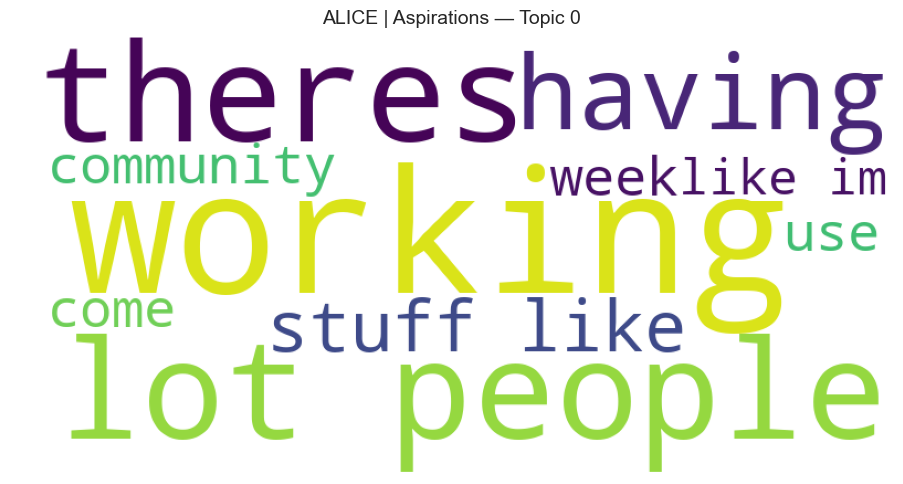

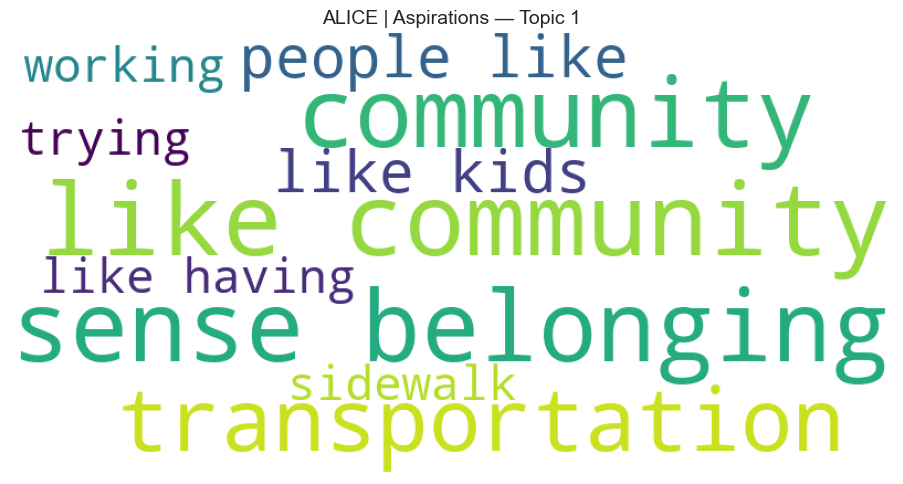

2026-04-24 10:53:49,231 - BERTopic - Embedding - Transforming documents to embeddings.



Running BERTopic: ALICE → Actions (31 docs)


Batches: 100%|██████████| 1/1 [00:04<00:00,  4.44s/it]
2026-04-24 10:53:53,686 - BERTopic - Embedding - Completed ✓
2026-04-24 10:53:53,687 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-24 10:53:53,733 - BERTopic - Dimensionality - Completed ✓
2026-04-24 10:53:53,734 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-24 10:53:53,742 - BERTopic - Cluster - Completed ✓
2026-04-24 10:53:53,753 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-24 10:54:00,891 - BERTopic - Representation - Completed ✓
2026-04-24 10:54:00,930 - BERTopic - Embedding - Transforming documents to embeddings.



Running BERTopic: Above_ALICE → Strengths (66 docs)


Batches: 100%|██████████| 3/3 [00:07<00:00,  2.55s/it]
2026-04-24 10:54:08,584 - BERTopic - Embedding - Completed ✓
2026-04-24 10:54:08,584 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-24 10:54:08,650 - BERTopic - Dimensionality - Completed ✓
2026-04-24 10:54:08,651 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-24 10:54:08,657 - BERTopic - Cluster - Completed ✓
2026-04-24 10:54:08,658 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-24 10:54:09,098 - BERTopic - Representation - Completed ✓


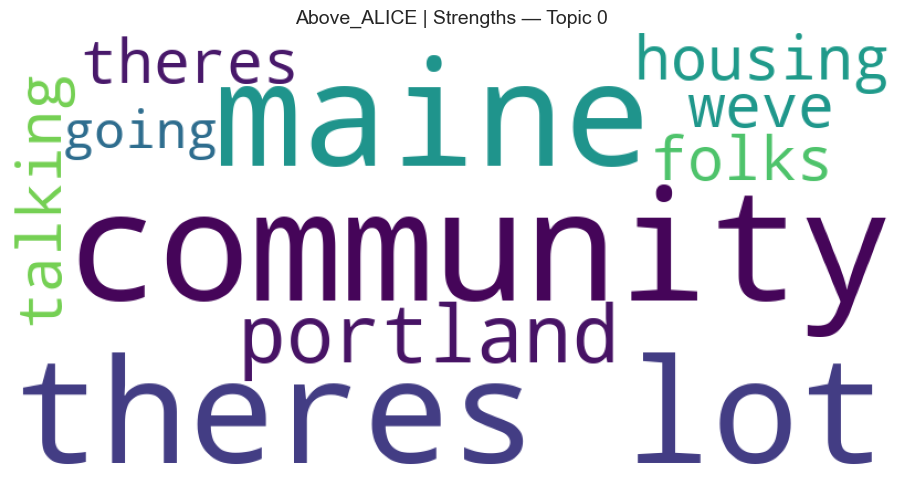

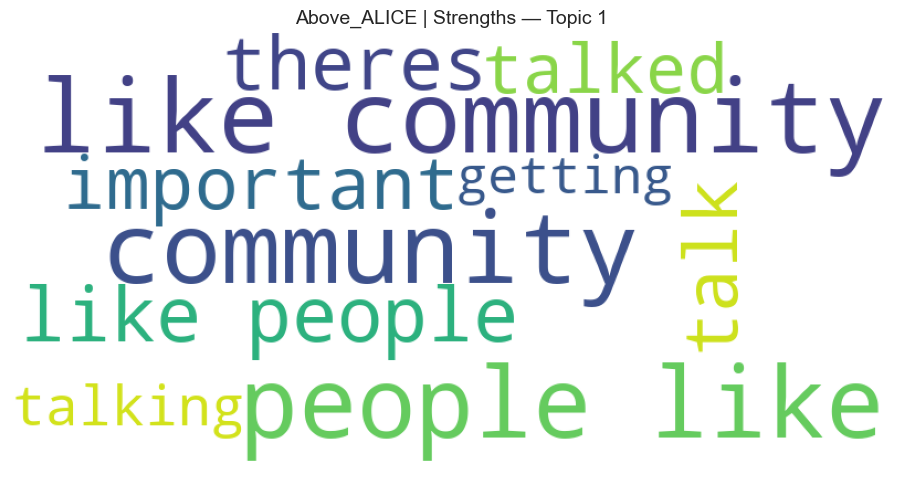

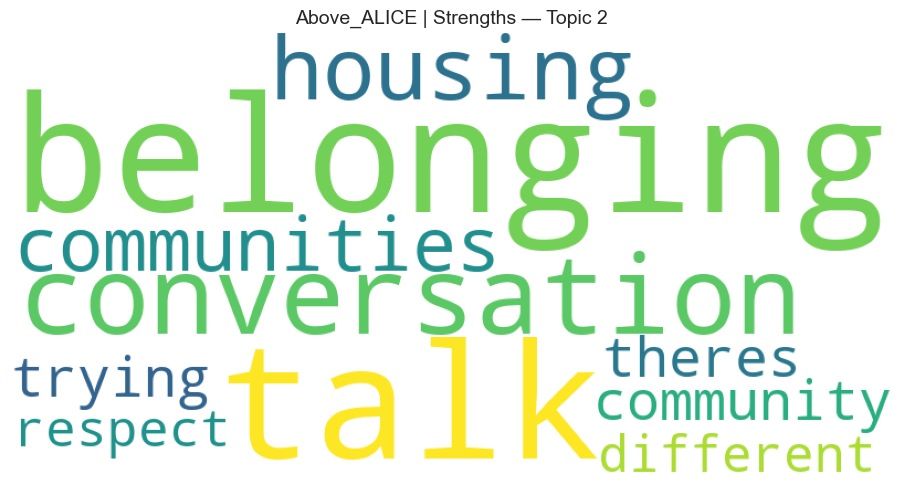

2026-04-24 10:54:09,826 - BERTopic - Embedding - Transforming documents to embeddings.



Running BERTopic: Above_ALICE → Challenges (73 docs)


Batches: 100%|██████████| 3/3 [00:07<00:00,  2.60s/it]
2026-04-24 10:54:17,625 - BERTopic - Embedding - Completed ✓
2026-04-24 10:54:17,625 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-24 10:54:17,702 - BERTopic - Dimensionality - Completed ✓
2026-04-24 10:54:17,703 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-24 10:54:17,708 - BERTopic - Cluster - Completed ✓
2026-04-24 10:54:17,710 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-24 10:54:18,165 - BERTopic - Representation - Completed ✓


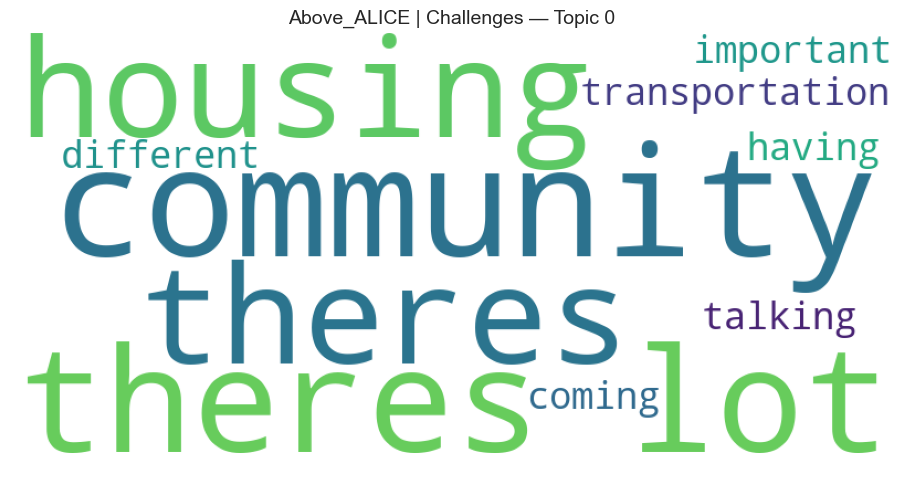

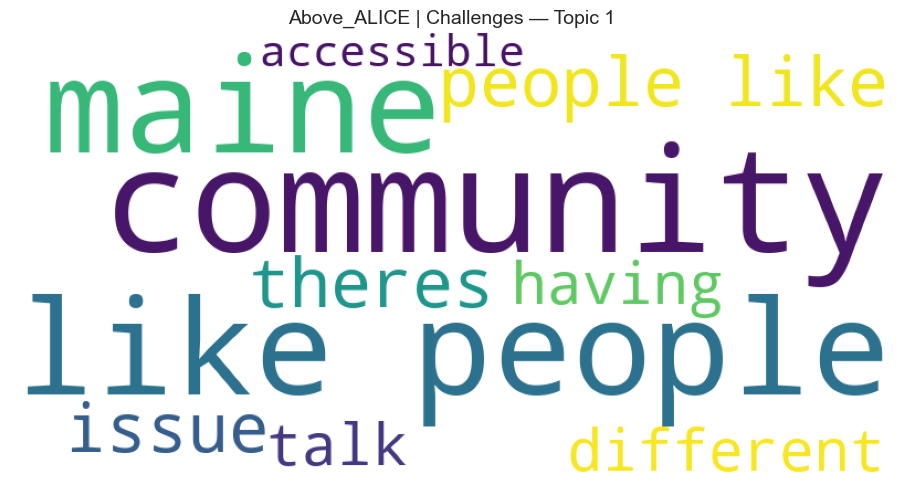

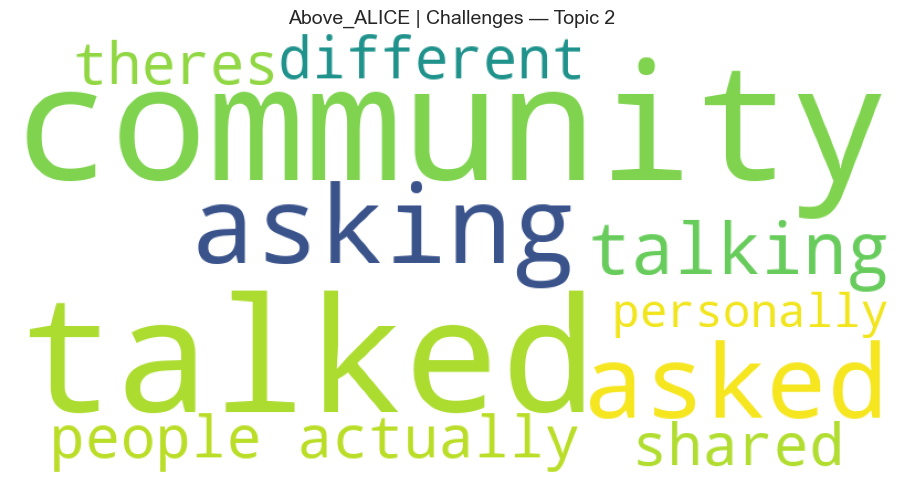

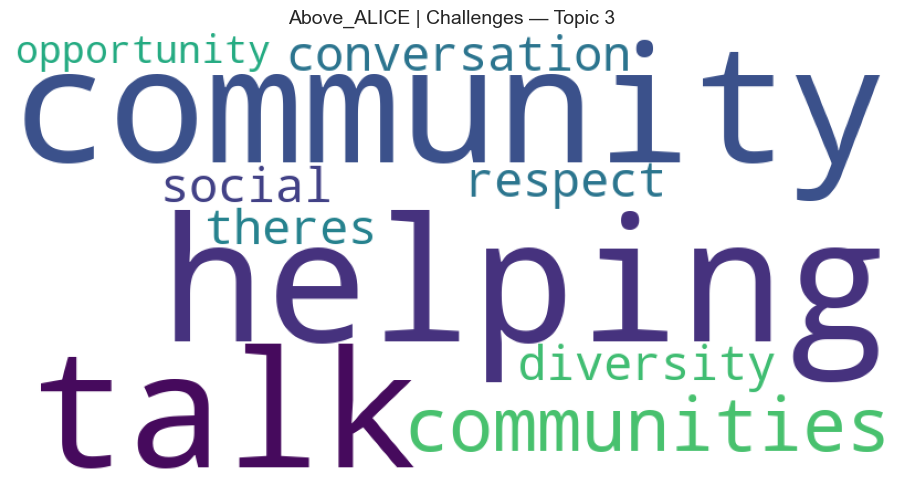

2026-04-24 10:54:19,066 - BERTopic - Embedding - Transforming documents to embeddings.



Running BERTopic: Above_ALICE → Aspirations (103 docs)


Batches: 100%|██████████| 4/4 [00:18<00:00,  4.66s/it]
2026-04-24 10:54:37,740 - BERTopic - Embedding - Completed ✓
2026-04-24 10:54:37,740 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-24 10:54:37,850 - BERTopic - Dimensionality - Completed ✓
2026-04-24 10:54:37,851 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-24 10:54:37,858 - BERTopic - Cluster - Completed ✓
2026-04-24 10:54:37,859 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-24 10:54:38,415 - BERTopic - Representation - Completed ✓


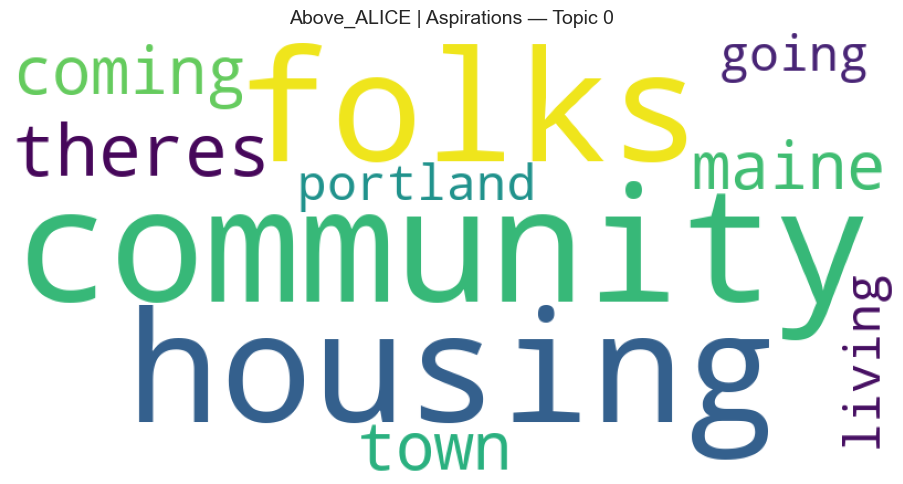

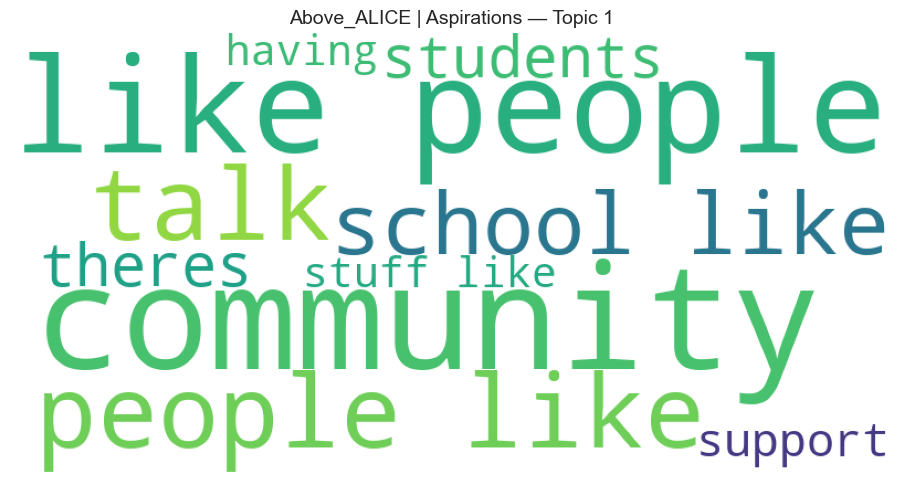

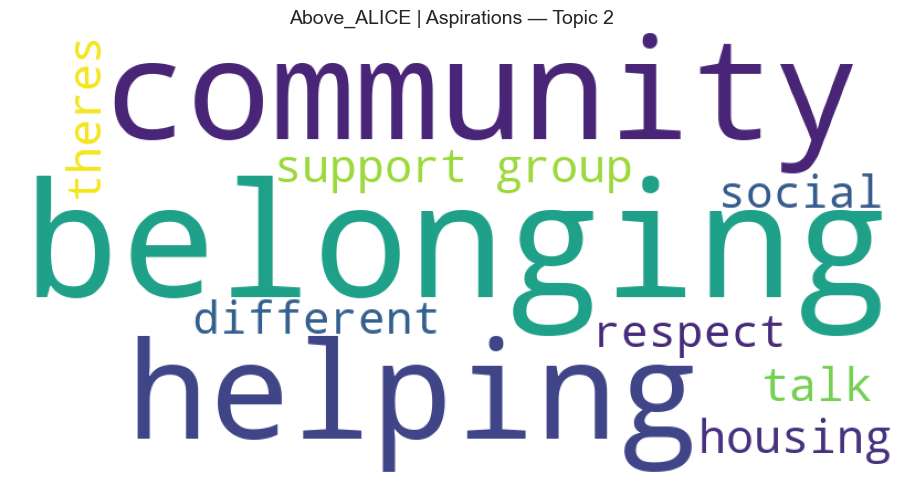

2026-04-24 10:54:39,103 - BERTopic - Embedding - Transforming documents to embeddings.



Running BERTopic: Above_ALICE → Actions (117 docs)


Batches: 100%|██████████| 4/4 [00:16<00:00,  4.18s/it]
2026-04-24 10:54:55,865 - BERTopic - Embedding - Completed ✓
2026-04-24 10:54:55,866 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-24 10:54:56,018 - BERTopic - Dimensionality - Completed ✓
2026-04-24 10:54:56,018 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-24 10:54:56,026 - BERTopic - Cluster - Completed ✓
2026-04-24 10:54:56,028 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-24 10:54:56,618 - BERTopic - Representation - Completed ✓


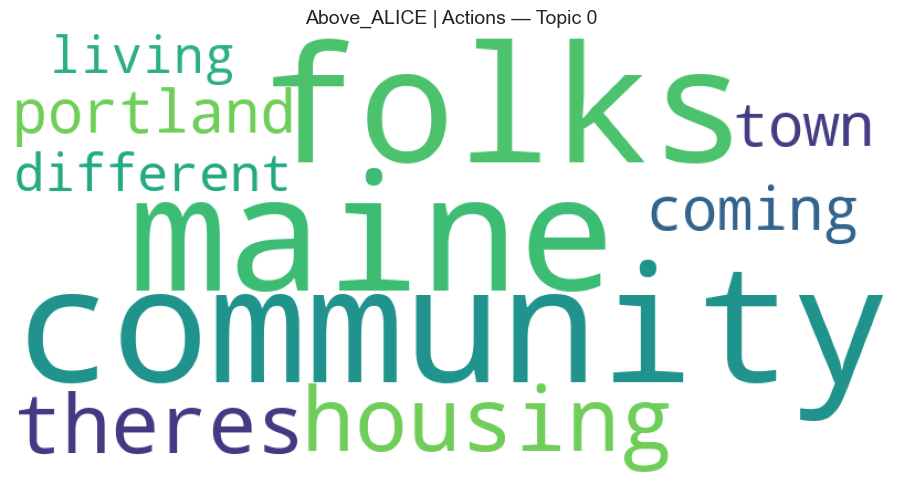

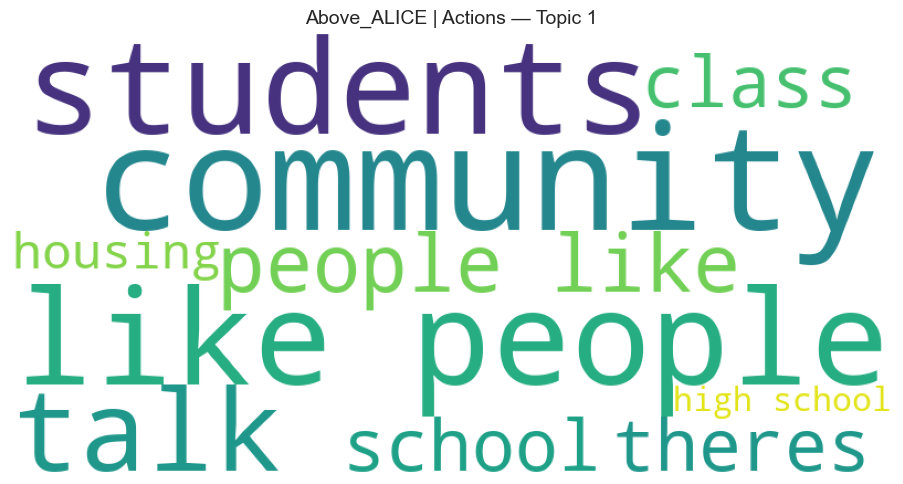

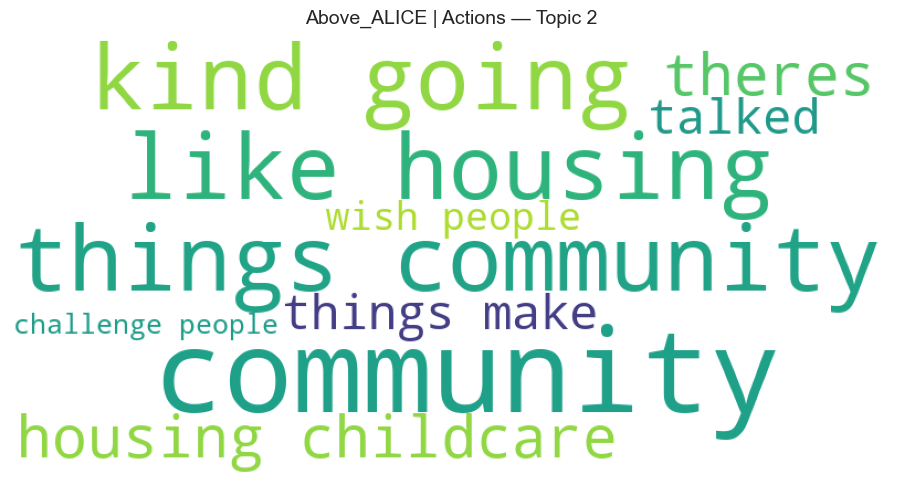

In [333]:
# Summary Analysis Question Keywords
import os
from sklearn.feature_extraction.text import CountVectorizer

question_map = {
    "Strengths": ["strength", "value", "resource", "helpful", "accessible"],
    "Challenges": ["hard", "struggle", "barrier", "difficult", "problem"],
    "Aspirations": ["want", "wish", "hope", "dream", "future", "community"],
    "Actions": ["should", "could", "need to", "improve", "make", "do"]
}

# Create wordcloud directory if it doesn't exist
os.makedirs("wordcloud", exist_ok=True)

# Create subsets for ALICE and Above ALICE
alice_subset = combined[combined["Predicted Label"] == "ALICE"]
above_alice_subset = combined[combined["Predicted Label"] == "Above ALICE"]

# Your three dataframes
group_map = {
    "ALICE": alice_subset,
    "Above_ALICE": above_alice_subset,
}

results = {}

for group_name, df in group_map.items():
    results[group_name] = {}

    for category, keywords in question_map.items():

        #df["clean_text"] = df["clean_text"].apply(remove_stop_words)

        mask = df["clean_text"].str.contains(
            "|".join(keywords), case=False, na=False
        )
        corpus = df.loc[mask, "clean_text"].tolist()

        if len(corpus) < 5:
            print(f"Skipping {group_name} → {category} — only {len(corpus)} docs, insufficient")
            continue

        print(f"\nRunning BERTopic: {group_name} → {category} ({len(corpus)} docs)")

        # Use fractional min_df (proportion) instead of absolute count
        # This automatically scales with corpus size and avoids vectorizer conflicts
        # min_df=0.1 means term must appear in at least 10% of documents

        topics, _ = topic_model.fit_transform(corpus)

        results[group_name][category] = {
            "corpus": corpus,
            "topics": topics,
            "topic_info": topic_model.get_topic_info()
        }

        # WordCloud per topic
        for topic_id in set(topics):
            if topic_id == -1:
                continue
            wc = wordcloud_for_topic(topic_model, topic_id)
            if wc:
                plt.figure(figsize=(10, 5))
                plt.title(f"{group_name} | {category} — Topic {topic_id}", fontsize=14)
                plt.imshow(wc)
                plt.axis("off")
                plt.tight_layout()
                plt.savefig(f"wordcloud/wc_{group_name}_{category}_topic{topic_id}.png", dpi=150)
                plt.show()

### **2D-Cluster Map**

In [335]:
import umap
import hdbscan
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
import torch

# ── Step 1: Device Setup ──────────────────────────────────────────────────────
dvc = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

# ── Step 2: BGE-Large Embeddings ──────────────────────────────────────────────
subset = combined[(combined["Predicted Label"] != "Facilitator") & (combined["Predicted Label"] != "ERROR")]
subset["clean_text"] = subset["clean_text"].apply(remove_stop_words)
docs = subset["clean_text"].tolist()
labels = subset["Predicted Label"].tolist()

docs_with_prefix = [f"Represent this community interview response: {doc}" for doc in docs]

bge_large = SentenceTransformer('BAAI/bge-large-en-v1.5')

bge_large_embeddings = bge_large.encode(
    docs_with_prefix,
    batch_size=16,
    show_progress_bar=True,
    normalize_embeddings=True,
    device=dvc,
    convert_to_numpy=True,
)

print(f"Embedding shape: {bge_large_embeddings.shape}")


# ── Step 3: 2D UMAP for Visualization ────────────────────────────────────────
umap_2d = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.0,
    metric='cosine',
    random_state=42,
)
embeddings_2d = umap_2d.fit_transform(bge_large_embeddings)


# ── Step 4: HDBSCAN Clustering ────────────────────────────────────────────────
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=2,
    min_samples=2,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
)
cluster_labels = clusterer.fit_predict(embeddings_2d)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)
print(f"Clusters found: {n_clusters} | Noise points removed: {n_noise}")


# ── Step 5: TF-IDF Keywords Per Cluster ───────────────────────────────────────
def get_cluster_keywords(docs, labels, top_n=5):
    cluster_keywords = {}
    for label in set(labels):
        if label == -1:
            continue
        cluster_docs = [docs[i] for i, l in enumerate(labels) if l == label]
        tfidf = TfidfVectorizer(
            stop_words='english',
            max_features=1000,
            ngram_range=(1, 2)
        )
        try:
            matrix = tfidf.fit_transform(cluster_docs)
            scores = matrix.mean(axis=0).A1
            top_idx = scores.argsort()[-top_n:][::-1]
            keywords = [tfidf.get_feature_names_out()[i] for i in top_idx]
            cluster_keywords[label] = ", ".join(keywords)
        except Exception:
            cluster_keywords[label] = "insufficient text"
    return cluster_keywords

cluster_keywords = get_cluster_keywords(docs, cluster_labels)


# ── Step 6: Build DataFrame ───────────────────────────────────────────────────
df_plot = pd.DataFrame({
    "x":            embeddings_2d[:, 0],
    "y":            embeddings_2d[:, 1],
    "cluster":      cluster_labels,
    "group":        labels,                                     # ALICE / Above ALICE
    "text_preview": [doc[:120] + "..." for doc in docs],
})

# Remove noise
df_plot = df_plot[df_plot["cluster"] != -1].copy()
df_plot["keywords"]     = df_plot["cluster"].map(cluster_keywords)
df_plot["cluster_str"]  = "Cluster " + df_plot["cluster"].astype(str)


# ── Step 7: Plot 1 — View By Unique Clusters ─────────────────────────────────
fig_clusters = px.scatter(
    df_plot,
    x="x",
    y="y",
    color="cluster_str",                # Color by cluster
    symbol="group",                     # Shape by ALICE / Above ALICE
    hover_data={
        "x":            False,
        "y":            False,
        "cluster_str":  True,
        "group":        True,
        "keywords":     True,
        "text_preview": True,
    },
    title="View 1 — All Unique Clusters (Shape = ALICE Group)",
    template="plotly_dark",
    width=1100,
    height=700,
    labels={
        "cluster_str":  "Cluster",
        "group":        "ALICE Group",
        "keywords":     "Top Keywords",
        "text_preview": "Transcript Preview",
    }
)

fig_clusters.update_traces(marker=dict(size=10, opacity=0.85))
fig_clusters.update_layout(
    legend_title_text="Cluster / Group",
    font=dict(size=13),
    title_font_size=17,
)

fig_clusters.show()
fig_clusters.write_html("view1_clusters.html")


# ── Step 8: Plot 2 — View By ALICE vs Above ALICE ────────────────────────────
fig_groups = px.scatter(
    df_plot,
    x="x",
    y="y",
    color="group",                      # Color by ALICE / Above ALICE
    symbol="cluster_str",               # Shape by cluster
    hover_data={
        "x":            False,
        "y":            False,
        "cluster_str":  True,
        "group":        True,
        "keywords":     True,
        "text_preview": True,
    },
    title="View 2 — ALICE vs Above ALICE Distribution Across Clusters",
    template="plotly_dark",
    color_discrete_map={
        "ALICE":        "#00B4D8",      # Blue  — ALICE
        "Above ALICE":  "#F77F00",      # Orange — Above ALICE
    },
    width=1100,
    height=700,
    labels={
        "cluster_str":  "Cluster",
        "group":        "ALICE Group",
        "keywords":     "Top Keywords",
        "text_preview": "Transcript Preview",
    }
)

fig_groups.update_traces(marker=dict(size=10, opacity=0.85))
fig_groups.update_layout(
    legend_title_text="ALICE Group / Cluster",
    font=dict(size=13),
    title_font_size=17,
)

fig_groups.show()
fig_groups.write_html("view2_groups.html")


# ── Step 9: Cluster Summary Table ────────────────────────────────────────────
summary = (
    df_plot.groupby(["cluster_str", "group"])
    .size()
    .reset_index(name="count")
    .pivot(index="cluster_str", columns="group", values="count")
    .fillna(0)
    .astype(int)
)
summary["Total"]    = summary.sum(axis=1)
summary["Keywords"] = summary.index.map(
    lambda c: cluster_keywords.get(int(c.split(" ")[1]), "")
)
print("\n── Cluster Summary ──────────────────────────────")
print(summary.to_string())

Batches: 100%|██████████| 10/10 [00:11<00:00,  1.12s/it]


Embedding shape: (160, 1024)
Clusters found: 25 | Noise points removed: 30



── Cluster Summary ──────────────────────────────
group        ALICE  Above ALICE  Total                                                            Keywords
cluster_str                                                                                               
Cluster 0        1            3      4                              say, school, community, different, job
Cluster 1        1            4      5               challenge, challenges, makes, challenges makes, goals
Cluster 10       0            3      3                        important, saying, wonderful, say, community
Cluster 11       2            7      9                                community, sanford, good, time, work
Cluster 12       1            4      5                             community, big, question, live, housing
Cluster 13       0            2      2                            music, team, families, family, biddeford
Cluster 14       2            3      5                                    work, harder, rent,

In [336]:
# ── Step 10: Class TF-IDF (cTF-IDF) Construction ────────────────────────────
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import normalize

# ── 10.1: Fit CountVectorizer on all documents ────────────────────────────
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=1000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)
count_matrix = vectorizer.fit_transform(docs)
feature_names = vectorizer.get_feature_names_out()
print(f"Vocabulary size: {len(feature_names)}")

# ── 10.2: Calculate cTF-IDF ────────────────────────────────────────────
# Group documents by cluster
ctfidf_scores = {}
ctfidf_weights = {}

for cluster_id in sorted(set(cluster_labels)):
    if cluster_id == -1:  # Skip noise
        continue
    
    # Get indices for this cluster
    cluster_mask = np.array(cluster_labels) == cluster_id
    
    # Calculate cluster TF (sum of term frequencies in cluster)
    cluster_tf = count_matrix[cluster_mask].sum(axis=0).A1
    
    # Calculate IDF (inverse document frequency across clusters)
    n_docs_per_cluster = np.array(
        [(np.array(cluster_labels) == c_id).sum() 
         for c_id in set(cluster_labels) if c_id != -1]
    )
    
    # Number of clusters containing each term
    docs_with_term = np.sum(count_matrix > 0, axis=0).A1
    idf = np.log(len(set(cluster_labels)) / (1 + docs_with_term))
    
    # Combine: cTF-IDF = TF * IDF (normalized)
    ctfidf = cluster_tf * idf
    ctfidf_scores[cluster_id] = ctfidf
    ctfidf_weights[cluster_id] = normalize([ctfidf])[0]  # L2 normalization

# ── 10.3: Extract Top cTF-IDF Terms Per Cluster ────────────────────────
ctfidf_keywords = {}
top_n = 10

for cluster_id in sorted(ctfidf_scores.keys()):
    scores = ctfidf_scores[cluster_id]
    top_indices = np.argsort(scores)[-top_n:][::-1]
    
    # Get terms with their scores
    terms_with_scores = [
        (feature_names[idx], scores[idx]) 
        for idx in top_indices if scores[idx] > 0
    ]
    
    ctfidf_keywords[cluster_id] = terms_with_scores
    
    print(f"\n── Cluster {cluster_id} (cTF-IDF Top Terms) ──")
    for term, score in terms_with_scores:
        print(f"  {term:20s} : {score:8.4f}")

# ── 10.4: Create cTF-IDF Summary DataFrame ────────────────────────────
ctfidf_summary = []

for cluster_id in sorted(ctfidf_keywords.keys()):
    terms_list = ctfidf_keywords[cluster_id]
    terms_str = ", ".join([t[0] for t in terms_list[:5]])
    scores_str = ", ".join([f"{t[1]:.3f}" for t in terms_list[:5]])
    
    n_docs_in_cluster = (np.array(cluster_labels) == cluster_id).sum()
    alice_count = sum(
        1 for i, label in enumerate(cluster_labels) 
        if label == cluster_id and labels[i] == "ALICE"
    )
    above_alice_count = n_docs_in_cluster - alice_count
    
    ctfidf_summary.append({
        "Cluster": cluster_id,
        "ALICE": alice_count,
        "Above ALICE": above_alice_count,
        "Total": n_docs_in_cluster,
        "cTF-IDF Terms": terms_str,
        "Scores": scores_str
    })

ctfidf_df = pd.DataFrame(ctfidf_summary)
print("\n── cTF-IDF Summary ──────────────────────────────")
print(ctfidf_df.to_string(index=False))

# ── 10.5: Update df_plot with cTF-IDF Keywords ────────────────────────
df_plot["ctfidf_keywords"] = df_plot["cluster"].apply(
    lambda c: ", ".join([t[0] for t in ctfidf_keywords.get(c, [])][:5]) 
    if c in ctfidf_keywords else "N/A"
)

print("\n✓ cTF-IDF construction complete!")
print(f"  • {len(ctfidf_keywords)} clusters analyzed")
print(f"  • {len(feature_names)} vocabulary terms")
print(f"  • Corpus: {count_matrix.shape[0]} documents")

Vocabulary size: 1000

── Cluster 0 (cTF-IDF Top Terms) ──
  ton                  :   5.8653
  knit                 :   4.3990
  scale                :   3.2973
  nature               :   3.1826
  minutes              :   3.0952
  serving              :   2.9327
  path                 :   2.9327
  smaller              :   2.9130
  difference           :   2.8665
  store                :   2.8665

── Cluster 1 (cTF-IDF Top Terms) ──
  systems              :   2.9327
  hard reach           :   2.6244
  makes hard           :   2.6244
  reach goals          :   2.6244
  healthcare           :   2.3573
  substance use        :   1.4663
  kinds                :   1.4663
  substance            :   1.4663
  health care          :   1.4663
  make life            :   1.3122

── Cluster 2 (cTF-IDF Top Terms) ──
  girls                :  15.4836
  narcan               :  15.1164
  boys                 :  14.1439
  prom                 :  13.1026
  south portland       :  11.7617
  football       